# Laboratorio 5: Frecuencias y n-gramas

Se utiliza `train_clean.csv`, generado en el notebook anterior, que ya contiene la columna `clean_text` con el texto preprocesado.

**Este notebook cubre:**
- Punto 4: Frecuencia de palabras (unigramas) por clase, discusión de palabras útiles para clasificación, bigramas y trigramas.

---

In [1]:
import warnings
warnings.filterwarnings("ignore")

from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer

pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 1. Carga del dataset preprocesado

In [2]:
df = pd.read_csv("./data/train_clean.csv")
df["clean_text"] = df["clean_text"].fillna("")  # por si algún texto quedó vacío tras la limpieza

df_desastre = df[df["target"] == 1]
df_no_desastre = df[df["target"] == 0]

print(f"Tweets 'desastre real' (1)  : {len(df_desastre):,}")
print(f"Tweets 'no desastre'   (0)  : {len(df_no_desastre):,}")
df.head(3)

Tweets 'desastre real' (1)  : 3,271
Tweets 'no desastre'   (0)  : 4,342


,id,keyword,location,text,clean_text,n_caracteres,n_palabras,clean_n_palabras,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,deeds reason earthquake may allah forgive us,69,13,7,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada,38,7,7,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place or...,residents asked shelter place notified officers evacuation shelter place orders expected,133,22,11,1


## 2. Frecuencia de palabras — unigramas (Punto 4)

Contamos cuántas veces aparece cada palabra en el texto limpio, por separado para cada clase.
Esto permite identificar qué palabras son más discriminantes para el modelo de clasificación.

In [3]:
def top_palabras(textos, n=20):
    contador = Counter()
    for t in textos:
        contador.update(t.split())
    return contador.most_common(n)


top_desastre = top_palabras(df_desastre["clean_text"], n=20)
top_no_desastre = top_palabras(df_no_desastre["clean_text"], n=20)

tabla_frecuencias = pd.DataFrame({
    "palabra_desastre": [p for p, _ in top_desastre],
    "freq_desastre": [f for _, f in top_desastre],
    "palabra_no_desastre": [p for p, _ in top_no_desastre],
    "freq_no_desastre": [f for _, f in top_no_desastre],
})
tabla_frecuencias

,palabra_desastre,freq_desastre,palabra_no_desastre,freq_no_desastre
0,fire,182,like,254
1,news,137,new,171
2,disaster,121,get,163
3,via,121,one,133
4,california,115,body,115
5,suicide,112,would,101
6,police,109,via,99
7,people,105,video,96
8,killed,95,people,94
9,like,94,love,91


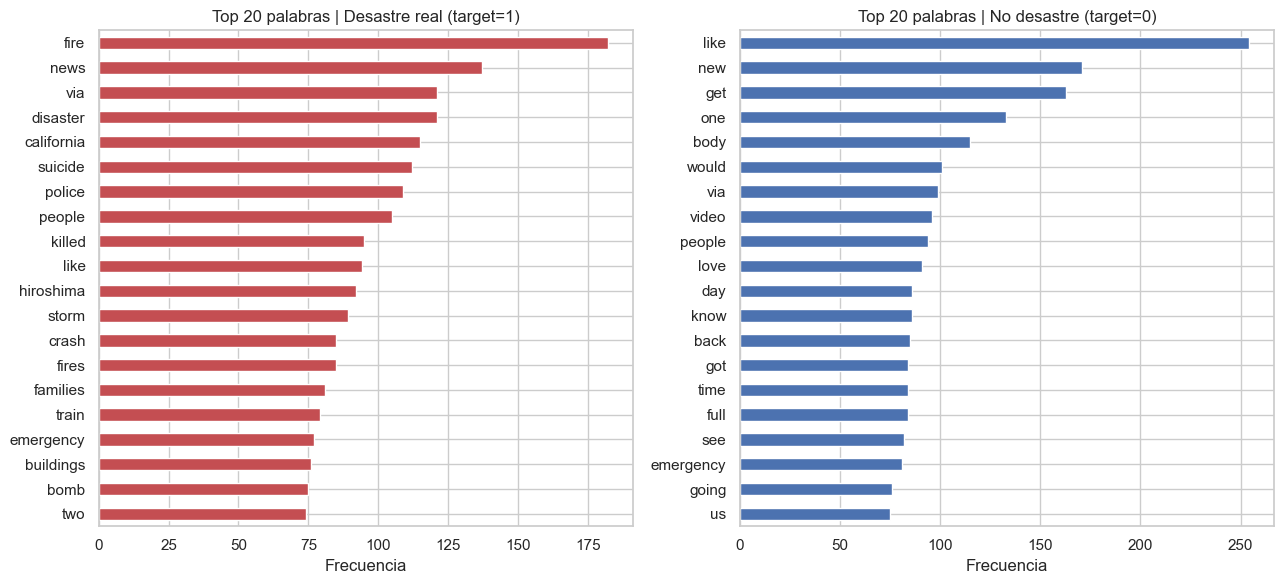

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

pd.Series(dict(top_desastre)).sort_values().plot(kind="barh", ax=axes[0], color="#C44E52")
axes[0].set_title("Top 20 palabras | Desastre real (target=1)")
axes[0].set_xlabel("Frecuencia")

pd.Series(dict(top_no_desastre)).sort_values().plot(kind="barh", ax=axes[1], color="#4C72B0")
axes[1].set_title("Top 20 palabras | No desastre (target=0)")
axes[1].set_xlabel("Frecuencia")

plt.tight_layout()
plt.show()

**Interpretación:** en la clase *desastre real* dominan palabras muy asociadas a eventos
concretos (`fire`, `news`, `disaster`, `killed`, `california`, `storm`, `police`, `suicide`,
`flood`...), mientras que en la clase *no desastre* aparecen palabras de uso coloquial/figurado en
Twitter (`like`, `im`, `get`, `new`, `body`, `via`) que se usan tanto en contextos literales como
metafóricos. Esto confirma que hay palabras con alto poder discriminante y otras que aportarán poco por sí solas.

## 3. Bigramas y trigramas: ¿vale la pena explorar el contexto? (Punto 4)

Un unigrama captura palabras sueltas, pero pierde el orden y el contexto inmediato. Por ejemplo,
"suicide bomber" (contexto de desastre real) y "not a bomber" tienen la palabra "bomber" en común,
pero significados muy distintos. Los **bigramas** (pares de palabras) y **trigramas** (tríos) capturan parte de ese contexto.

In [5]:
def top_ngramas(textos, ngram_range, n=15):
    vectorizador = CountVectorizer(ngram_range=ngram_range)
    matriz = vectorizador.fit_transform(textos)
    frecuencias = np.asarray(matriz.sum(axis=0)).ravel()
    vocabulario = vectorizador.get_feature_names_out()
    conteo = pd.Series(frecuencias, index=vocabulario).sort_values(ascending=False)
    return conteo.head(n)


bigramas_desastre = top_ngramas(df_desastre["clean_text"], (2, 2))
bigramas_no_desastre = top_ngramas(df_no_desastre["clean_text"], (2, 2))

pd.DataFrame({
    "bigrama_desastre": bigramas_desastre.index, "freq": bigramas_desastre.values,
}).join(pd.DataFrame({
    "bigrama_no_desastre": bigramas_no_desastre.index, "freq_2": bigramas_no_desastre.values,
}))

,bigrama_desastre,freq,bigrama_no_desastre,freq_2
0,suicide bomber,59,cross body,39
1,northern california,41,liked video,34
2,oil spill,38,full read,28
3,burning buildings,36,body bag,27
4,suicide bombing,35,body bagging,24
5,california wildfire,34,burning buildings,23
6,bomber detonated,30,body bags,22
7,confirmed mh370,29,looks like,21
8,homes razed,29,reddit quarantine,21
9,year old,28,quarantine offensive,21


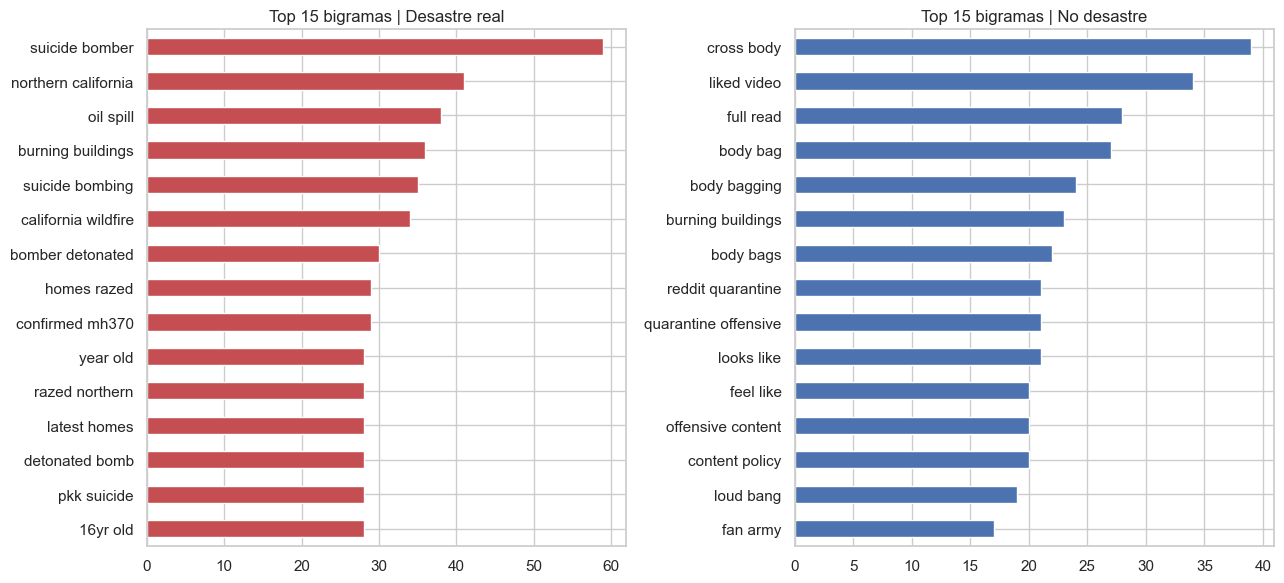

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

bigramas_desastre.sort_values().plot(kind="barh", ax=axes[0], color="#C44E52")
axes[0].set_title("Top 15 bigramas | Desastre real")

bigramas_no_desastre.sort_values().plot(kind="barh", ax=axes[1], color="#4C72B0")
axes[1].set_title("Top 15 bigramas | No desastre")

plt.tight_layout()
plt.show()

In [7]:
trigramas_desastre = top_ngramas(df_desastre["clean_text"], (3, 3), n=10)
trigramas_no_desastre = top_ngramas(df_no_desastre["clean_text"], (3, 3), n=10)

print("Top 10 trigramas | Desastre real:")
display(trigramas_desastre)

print("\nTop 10 trigramas | No desastre:")
display(trigramas_no_desastre)

Top 10 trigramas | Desastre real:


suicide bomber detonated        30
northern california wildfire    29
pkk suicide bomber              28
latest homes razed              28
bomber detonated bomb           28
homes razed northern            28
razed northern california       27
old pkk suicide                 27
16yr old pkk                    27
families affected fatal         26
dtype: int64


Top 10 trigramas | No desastre:


reddit quarantine offensive     21
quarantine offensive content    20
cross body bag                  19
pick fan army                   17
china stock market              16
stock market crash              16
reddit new content              16
new content policy              16
knock detonation sensor         15
horrible subreddits banned      15
dtype: int64

**Discusión — ¿vale la pena explorar bigramas/trigramas?** Sí, claramente aportan valor de
contexto: bigramas como *"suicide bomber"*, *"northern california"*, *"burning buildings"* o
*"oil spill"* son mucho más específicos y menos ambiguos que sus palabras sueltas, y aparecen casi
exclusivamente del lado de desastre real. Los trigramas son más escasos (la frecuencia cae rápido
al aumentar `n`, efecto esperado en texto corto como un tweet) pero aun así confirman patrones de frases hechas.

**Conclusión para el modelado:** conviene probar el vectorizador con `ngram_range=(1, 2)` (unigramas + bigramas) como
*feature* del modelo, ya que agrega contexto sin disparar demasiado la dimensionalidad; los trigramas aportan menos por su baja frecuencia en tweets tan cortos.

## 4. Resumen

- Las palabras más frecuentes en *desastre real* son términos factuales de emergencias (`fire`, `flood`, `killed`, `storm`).
- En *no desastre* dominan palabras de uso genérico/coloquial en Twitter que no ayudan a discriminar por sí solas.
- Los **bigramas sí aportan valor** de contexto y se recomienda incluir `ngram_range=(1, 2)` en el vectorizador del modelo.
- Los trigramas tienen utilidad limitada en tweets cortos por su baja frecuencia.